## UC00240: Smart Street & Road Lighting Design
**Authored by:** Ved Sharma

**Duration:** 90 mins

**Level:** Intermediate

**Pre-requisite Skills:** Python, Pandas, Matplotlib, Working with APIs, Basic Geospatial Concepts

---

## Scenario

Urban street lighting in Melbourne runs on fixed schedules that have nothing to do with how people actually use the streets. Some streets stay brightly lit at 3am with barely anyone around, while genuinely busy spots during the evening are under-lit and not particularly safe.

In this use case, I built a preliminary pipeline that combines two real Melbourne Open Data datasets to identify where the current lighting doesn't match foot traffic, and to generate a basic streetlight placement recommendation for a given street. This is a baseline system at this stage, with LLM integration planned as the next phase.

---

## User Story

As a city planner or urban infrastructure designer, I want to receive streetlight placement recommendations based on real pedestrian activity data, so that I can design lighting systems that improve public safety and reduce wasted energy across Melbourne's streets and roads.

---

## What This Use Case Will Teach You

- How to load real open datasets from Melbourne Open Data using API calls
- How to clean and merge pedestrian and streetlight data from multiple sources
- How to extract GPS coordinates and use them for spatial analysis
- How to identify lighting inefficiencies using nearest neighbour matching
- How to build a baseline recommendation engine that generates lighting design proposals from real data


---
## Step 1: Imports and Setup

First I imported the libraries needed for this project. The main ones are `pandas` for data handling, `matplotlib` for charts, `sklearn` for the spatial matching, and `requests` to pull data directly from the Melbourne Open Data API.


In [24]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import warnings
from io import StringIO
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
warnings.filterwarnings('ignore')

# This function loads a dataset from the Melbourne Open Data portal.
# It builds the URL using the dataset name, sends a GET request, and returns a DataFrame.
# Using CSV format with semicolon separator — that's just how this API returns the data.
def load_dataset(dataset_name, limit=5000):
    base_url = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/' + dataset_name + '/exports/csv'
    params = {'limit': limit, 'format': 'csv'}
    try:
        response = requests.get(base_url, params=params, timeout=30)
        if response.status_code == 200:
            return pd.read_csv(StringIO(response.content.decode('utf-8')), sep=';')
        else:
            print('API call failed, status:', response.status_code)
            return None
    except Exception as e:
        print('Error:', e)
        return None

# Load both datasets
pedestrian_data = load_dataset('pedestrian-counting-system-monthly-counts-per-hour')
streetlight_data = load_dataset('street-lights-with-emitted-lux-level-council-owned-lights-only')

print('Pedestrian data loaded:', pedestrian_data.shape)
print('Streetlight data loaded:', streetlight_data.shape)


Pedestrian data loaded: (5000, 9)
Streetlight data loaded: (5000, 21)


---
## Step 2: Preview the Data

Before doing anything, I check what columns are available in both datasets.


In [25]:
pedestrian_data.head()


,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location
0,1332320260227,133,2026-02-27,23,983,359,1342,Spen229_T,"-37.81531435, 144.95227769"
1,1841520251203,184,2025-12-03,15,882,1036,1918,Eli124_T,"-37.81512416, 144.96371988"
2,1841220260110,184,2026-01-10,12,962,991,1953,Eli124_T,"-37.81512416, 144.96371988"
3,181220241119,18,2024-11-19,12,256,286,542,Col12_T,"-37.81344862, 144.97305353"
4,63120250326,63,2025-03-26,1,1,14,15,Bou231_T,"-37.81333081, 144.96675571"


In [26]:
streetlight_data.head()


,geo_point_2d,geo_shape,prop_id,name,addresspt1,xorg,ext_id,asset_clas,label,asset_type,...,northing,str_id,addresspt,asset_subt,xsource,profile,xdate,xdrawing,mcc_id,roadseg_id
0,"-37.80248700036199, 144.97010800026925","{""coordinates"": [144.97010800026925, -37.80248...",0,NaN,0.0,ESG,16180,NaN,0.293,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0
1,"-37.80109000004725, 144.9702759997199","{""coordinates"": [144.9702759997199, -37.801090...",0,NaN,0.0,ESG,14906,NaN,1.564,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0
2,"-37.80109000004725, 144.9702759997199","{""coordinates"": [144.9702759997199, -37.801090...",0,NaN,0.0,ESG,14938,NaN,1.564,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0
3,"-37.80109000004725, 144.9702759997199","{""coordinates"": [144.9702759997199, -37.801090...",0,NaN,0.0,ESG,14786,NaN,1.564,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0
4,"-37.80139999999262, 144.97399300005355","{""coordinates"": [144.97399300005355, -37.80139...",0,NaN,0.0,ESG,12807,NaN,3.030,NaN,...,0.0,0,0,NaN,NaN,NaN,20140916,NaN,0,0


---
## Step 3: Column Overview and Missing Values

Checking the column names and missing values upfront makes the cleaning step a lot easier to plan.


In [27]:
print('Pedestrian columns:', pedestrian_data.columns.tolist())
print('\nStreetlight columns:', streetlight_data.columns.tolist())


Pedestrian columns: ['id', 'location_id', 'sensing_date', 'hourday', 'direction_1', 'direction_2', 'pedestriancount', 'sensor_name', 'location']

Streetlight columns: ['geo_point_2d', 'geo_shape', 'prop_id', 'name', 'addresspt1', 'xorg', 'ext_id', 'asset_clas', 'label', 'asset_type', 'easting', 'northing', 'str_id', 'addresspt', 'asset_subt', 'xsource', 'profile', 'xdate', 'xdrawing', 'mcc_id', 'roadseg_id']


In [28]:
print('Pedestrian missing values:\n', pedestrian_data.isnull().sum())
print('\nStreetlight missing values:\n', streetlight_data.isnull().sum())


Pedestrian missing values:
 id                 0
location_id        0
sensing_date       0
hourday            0
direction_1        0
direction_2        0
pedestriancount    0
sensor_name        0
location           0
dtype: int64

Streetlight missing values:
 geo_point_2d       0
geo_shape          0
prop_id            0
name            5000
addresspt1         0
xorg               0
ext_id             0
asset_clas      5000
label              0
asset_type      5000
easting            0
northing           0
str_id             0
addresspt          0
asset_subt      5000
xsource         5000
profile         5000
xdate              0
xdrawing        5000
mcc_id             0
roadseg_id         0
dtype: int64


---
## Step 4: Data Cleaning

### Cleaning the Streetlight Dataset

The streetlight dataset has several columns that are entirely empty, like `name`, `asset_clas`, `asset_type`, and `asset_subt`. These are asset management fields that aren't useful here, so I drop them. The key column I need is `label`, which holds the lux (brightness) rating of each light.


In [29]:
# Drop columns that are completely empty or not relevant to our analysis
cols_to_drop = ['name', 'asset_clas', 'asset_type', 'asset_subt']
cols_to_drop = [c for c in cols_to_drop if c in streetlight_data.columns]
streetlight_clean = streetlight_data.drop(columns=cols_to_drop)
streetlight_clean = streetlight_clean.dropna(subset=['geo_point_2d'])

# Convert the lux column to numeric (it sometimes loads as a string)
streetlight_clean['label'] = pd.to_numeric(streetlight_clean['label'], errors='coerce')
streetlight_clean = streetlight_clean.dropna(subset=['label'])

print('Streetlight records after cleaning:', len(streetlight_clean))
streetlight_clean.head()


Streetlight records after cleaning: 5000


,geo_point_2d,geo_shape,prop_id,addresspt1,xorg,ext_id,label,easting,northing,str_id,addresspt,xsource,profile,xdate,xdrawing,mcc_id,roadseg_id
0,"-37.80248700036199, 144.97010800026925","{""coordinates"": [144.97010800026925, -37.80248...",0,0.0,ESG,16180,0.293,0.0,0.0,0,0,NaN,NaN,20140916,NaN,0,0
1,"-37.80109000004725, 144.9702759997199","{""coordinates"": [144.9702759997199, -37.801090...",0,0.0,ESG,14906,1.564,0.0,0.0,0,0,NaN,NaN,20140916,NaN,0,0
2,"-37.80109000004725, 144.9702759997199","{""coordinates"": [144.9702759997199, -37.801090...",0,0.0,ESG,14938,1.564,0.0,0.0,0,0,NaN,NaN,20140916,NaN,0,0
3,"-37.80109000004725, 144.9702759997199","{""coordinates"": [144.9702759997199, -37.801090...",0,0.0,ESG,14786,1.564,0.0,0.0,0,0,NaN,NaN,20140916,NaN,0,0
4,"-37.80139999999262, 144.97399300005355","{""coordinates"": [144.97399300005355, -37.80139...",0,0.0,ESG,12807,3.030,0.0,0.0,0,0,NaN,NaN,20140916,NaN,0,0


### Cleaning the Pedestrian Dataset

For the pedestrian data, the main cleaning steps are removing rows with missing location or count values, filtering out negative pedestrian counts (which are sensor errors), parsing the date column to a proper datetime type, and adding a `total_foot_traffic` column that combines both directional counts. I also classify each reading into a time period based on the hour. The four periods are Morning, Daytime, Evening, and Night, since lighting needs vary quite a bit across the day.


In [30]:
print('Pedestrian records before cleaning:', len(pedestrian_data))

ped_clean = pedestrian_data.dropna(subset=['location', 'pedestriancount']).copy()
ped_clean = ped_clean[ped_clean['pedestriancount'] >= 0]
ped_clean['sensing_date'] = pd.to_datetime(ped_clean['sensing_date'], errors='coerce')
ped_clean = ped_clean.dropna(subset=['sensing_date'])

# Combine both directional counts into a single foot traffic figure
ped_clean['total_foot_traffic'] = ped_clean['direction_1'] + ped_clean['direction_2']

# Classify by time of day as this is important for lighting decisions
def classify_time_period(hour):
    if 6 <= hour <= 9:
        return 'Morning'
    elif 17 <= hour <= 20:
        return 'Evening'
    elif hour >= 21 or hour <= 5:
        return 'Night'
    else:
        return 'Daytime'

ped_clean['time_period'] = ped_clean['hourday'].apply(classify_time_period)

print('Pedestrian records after cleaning:', len(ped_clean))
print('\nTime period distribution:')
print(ped_clean['time_period'].value_counts())
ped_clean.head()


Pedestrian records before cleaning: 5000
Pedestrian records after cleaning: 5000

Time period distribution:
time_period
Night      1732
Daytime    1538
Morning     874
Evening     856
Name: count, dtype: int64


,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location,total_foot_traffic,time_period
0,1332320260227,133,2026-02-27,23,983,359,1342,Spen229_T,"-37.81531435, 144.95227769",1342,Night
1,1841520251203,184,2025-12-03,15,882,1036,1918,Eli124_T,"-37.81512416, 144.96371988",1918,Daytime
2,1841220260110,184,2026-01-10,12,962,991,1953,Eli124_T,"-37.81512416, 144.96371988",1953,Daytime
3,181220241119,18,2024-11-19,12,256,286,542,Col12_T,"-37.81344862, 144.97305353",542,Daytime
4,63120250326,63,2025-03-26,1,1,14,15,Bou231_T,"-37.81333081, 144.96675571",15,Night


---
## Step 5: Extract GPS Coordinates

Both datasets store location as a single string like `-37.813, 144.969`. I need to split these into separate latitude and longitude columns before any spatial analysis can happen.


In [31]:
# Split the location string into separate lat/lon columns
ped_split = ped_clean['location'].str.strip().str.split(',', expand=True)
ped_clean['Latitude'] = pd.to_numeric(ped_split[0].str.strip(), errors='coerce')
ped_clean['Longitude'] = pd.to_numeric(ped_split[1].str.strip(), errors='coerce')
ped_clean = ped_clean.dropna(subset=['Latitude', 'Longitude'])

sl_split = streetlight_clean['geo_point_2d'].str.strip().str.split(',', expand=True)
streetlight_clean = streetlight_clean.copy()
streetlight_clean['Latitude'] = pd.to_numeric(sl_split[0].str.strip(), errors='coerce')
streetlight_clean['Longitude'] = pd.to_numeric(sl_split[1].str.strip(), errors='coerce')
streetlight_clean = streetlight_clean.dropna(subset=['Latitude', 'Longitude'])

print('Pedestrian coordinate sample:')
print(ped_clean[['Latitude', 'Longitude']].head())
print('\nStreetlight coordinate sample:')
print(streetlight_clean[['Latitude', 'Longitude']].head())


Pedestrian coordinate sample:
    Latitude   Longitude
0 -37.815314  144.952278
1 -37.815124  144.963720
2 -37.815124  144.963720
3 -37.813449  144.973054
4 -37.813331  144.966756

Streetlight coordinate sample:
    Latitude   Longitude
0 -37.802487  144.970108
1 -37.801090  144.970276
2 -37.801090  144.970276
3 -37.801090  144.970276
4 -37.801400  144.973993


---
## Step 6: Matching Pedestrian Sensors to Nearest Streetlights

Here I connect the two datasets spatially. For each pedestrian sensor, I find the single closest streetlight using k-Nearest Neighbours with k=1. This lets me compare how bright the nearest light is against how many people are actually walking past it, which is the core of the efficiency analysis.


In [32]:
ped_coords   = ped_clean[['Latitude', 'Longitude']].to_numpy()
light_coords = streetlight_clean[['Latitude', 'Longitude']].to_numpy()

# Fit the kNN model on streetlight coordinates, then find nearest light for each sensor
nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(light_coords)
distances, indices = nbrs.kneighbors(ped_coords)

ped_clean['Nearest_Light_Index'] = indices.flatten()
ped_clean['Distance_to_Light']   = distances.flatten()
ped_clean['Nearest_Light_Lux']   = ped_clean['Nearest_Light_Index'].apply(
    lambda i: streetlight_clean.iloc[i]['label']
)

print('Distances to nearest streetlight (first 5):')
print(distances[:5])
ped_clean[['sensor_name', 'total_foot_traffic', 'Nearest_Light_Lux', 'Distance_to_Light']].head()


Distances to nearest streetlight (first 5):
[[0.00406512]
 [0.00068101]
 [0.00068101]
 [0.00146652]
 [0.00087352]]


,sensor_name,total_foot_traffic,Nearest_Light_Lux,Distance_to_Light
0,Spen229_T,1342,29.717,0.004065
1,Eli124_T,1918,40.958,0.000681
2,Eli124_T,1953,40.958,0.000681
3,Col12_T,542,1.466,0.001467
4,Bou231_T,15,22.874,0.000874


---
## Step 7: Identifying Lighting Inefficiencies

With each sensor linked to its nearest light, I can flag two types of mismatches. The first is overlit areas with low traffic, where lux is above 50 but fewer than 100 pedestrians pass per hour, which represents wasted energy. The second is underlit areas with high traffic, where more than 500 pedestrians pass per hour but the nearest light is below 10 lux, which is a safety concern.


In [33]:
over_lit = ped_clean[
    (ped_clean['total_foot_traffic'] < 100) & (ped_clean['Nearest_Light_Lux'] > 50)
].sort_values('Nearest_Light_Lux', ascending=False)

under_lit = ped_clean[
    (ped_clean['total_foot_traffic'] > 500) & (ped_clean['Nearest_Light_Lux'] < 10)
].sort_values('total_foot_traffic', ascending=False)

print('Over-lit and low foot traffic:')
print(over_lit[['sensor_name', 'total_foot_traffic', 'Nearest_Light_Lux']].head())
print('\nUnder-lit and high foot traffic:')
print(under_lit[['sensor_name', 'total_foot_traffic', 'Nearest_Light_Lux']].head())


Over-lit and low foot traffic:
     sensor_name  total_foot_traffic  Nearest_Light_Lux
4952    RMIT14_T                  92             99.316
848       RMIT_T                  78             99.316
3656      RMIT_T                  14             99.316
937     RMIT14_T                  38             99.316
973       RMIT_T                  66             99.316

Under-lit and high foot traffic:
     sensor_name  total_foot_traffic  Nearest_Light_Lux
4232    Swa123_T                3849              9.873
1356    Swa123_T                3701              9.873
246        Swa31                3584              9.580
2360    Swa123_T                3579              9.873
2075       Swa31                3551              9.580


---
## Step 8: Visualising Foot Traffic vs Brightness

This scatter plot shows the relationship between pedestrian activity and the brightness of the nearest streetlight. Ideally you'd see higher lux where there are more people, but the spread here shows that's often not the case.


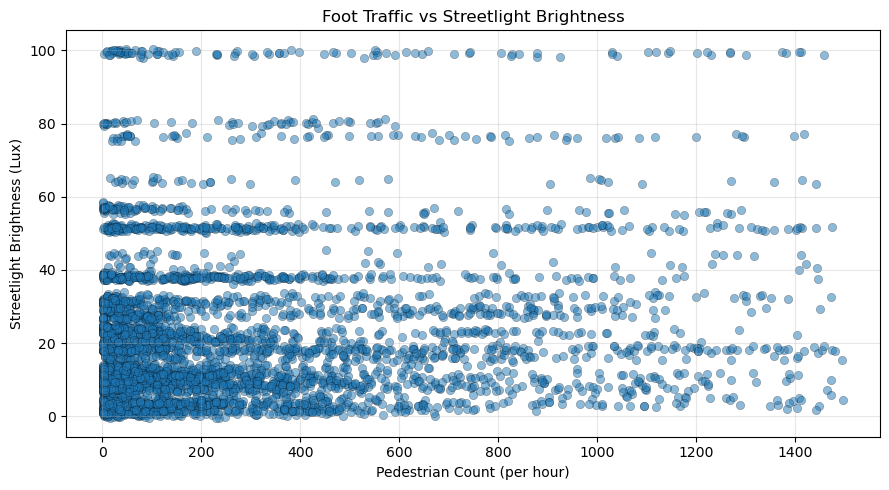

In [34]:
filtered = ped_clean[ped_clean['total_foot_traffic'] < 1500].copy()
jittered_lux = filtered['Nearest_Light_Lux'] + np.random.normal(0, 0.5, size=len(filtered))

plt.figure(figsize=(9, 5))
plt.scatter(filtered['total_foot_traffic'], jittered_lux, alpha=0.5, edgecolors='k', linewidth=0.3)
plt.xlabel('Pedestrian Count (per hour)')
plt.ylabel('Streetlight Brightness (Lux)')
plt.title('Foot Traffic vs Streetlight Brightness')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Step 9: Time-Based Pedestrian Analysis

Understanding when people are on the streets is important for smart lighting design. The charts below show average foot traffic across the hours of the day and broken down by time period.


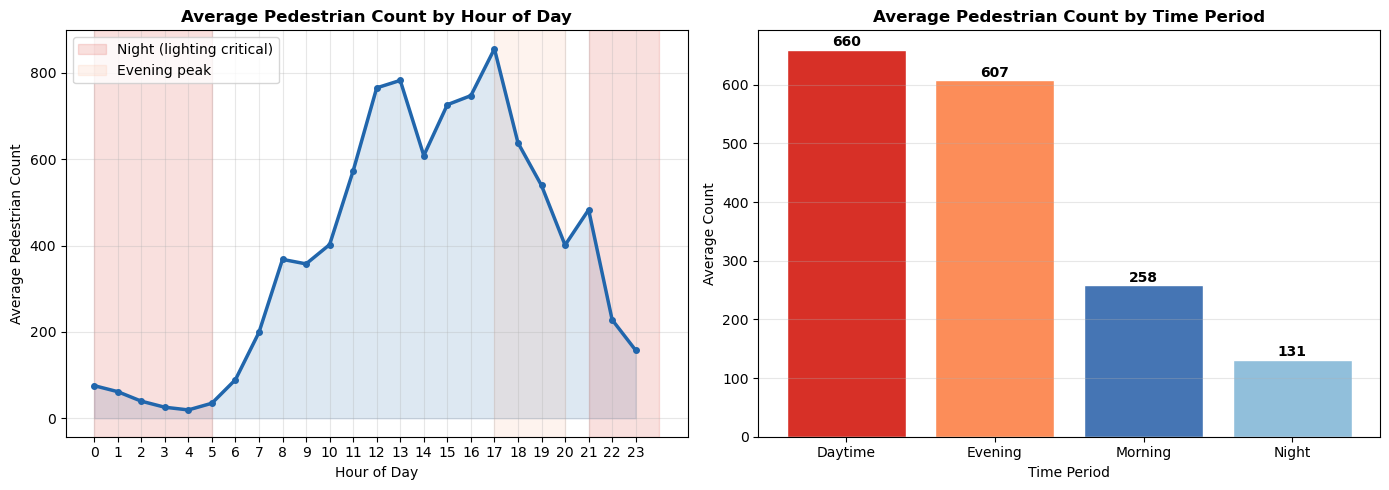

In [35]:
hourly_avg = ped_clean.groupby('hourday')['pedestriancount'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly_avg.index, hourly_avg.values, color='#2166ac', linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.15, color='#2166ac')
axes[0].axvspan(21, 24, alpha=0.15, color='#d73027', label='Night (lighting critical)')
axes[0].axvspan(0, 5, alpha=0.15, color='#d73027')
axes[0].axvspan(17, 20, alpha=0.1, color='#fc8d59', label='Evening peak')
axes[0].set_title('Average Pedestrian Count by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Pedestrian Count')
axes[0].set_xticks(range(0, 24))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

period_avg = ped_clean.groupby('time_period')['pedestriancount'].mean().sort_values(ascending=False)
colours = ['#d73027', '#fc8d59', '#4575b4', '#91bfdb']
bars = axes[1].bar(period_avg.index, period_avg.values, color=colours[:len(period_avg)], edgecolor='white')
axes[1].set_title('Average Pedestrian Count by Time Period', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Period')
axes[1].set_ylabel('Average Count')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, period_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


---
## Step 10: Calculating Suggested Lux Levels

Based on pedestrian activity at each sensor, I calculate what lux level would be appropriate and compare it to what the nearest light actually provides. A positive difference means the area is underlit and a negative difference means it's overlit.


In [36]:
def suggest_lux(foot_traffic):
    if foot_traffic < 50:
        return 20
    elif foot_traffic < 300:
        return 40
    else:
        return 70

ped_clean['Suggested_Lux'] = ped_clean['total_foot_traffic'].apply(suggest_lux)
ped_clean['Lux_Difference'] = ped_clean['Suggested_Lux'] - ped_clean['Nearest_Light_Lux']

ped_clean[['sensor_name', 'total_foot_traffic', 'Nearest_Light_Lux', 'Suggested_Lux', 'Lux_Difference']].head()


,sensor_name,total_foot_traffic,Nearest_Light_Lux,Suggested_Lux,Lux_Difference
0,Spen229_T,1342,29.717,70,40.283
1,Eli124_T,1918,40.958,70,29.042
2,Eli124_T,1953,40.958,70,29.042
3,Col12_T,542,1.466,70,68.534
4,Bou231_T,15,22.874,20,-2.874


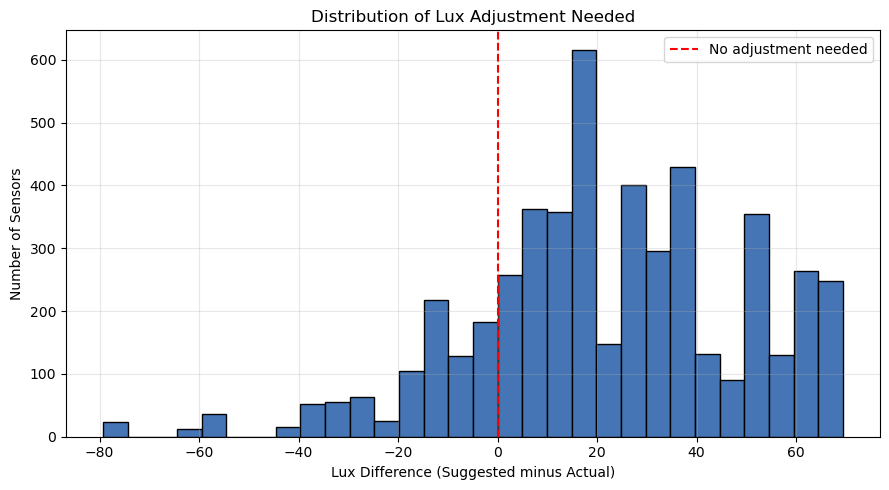

In [37]:
plt.figure(figsize=(9, 5))
plt.hist(ped_clean['Lux_Difference'], bins=30, edgecolor='black', color='#4575b4')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No adjustment needed')
plt.title('Distribution of Lux Adjustment Needed')
plt.xlabel('Lux Difference (Suggested minus Actual)')
plt.ylabel('Number of Sensors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Step 11: Efficiency Classification

I classify each sensor location into one of three categories so city planners can quickly see where action is needed. Efficient means the foot traffic and lux are reasonably matched. Underlit means high traffic but not enough light, which is a safety risk. Overlit means low traffic but too much light, which is an energy-saving opportunity.


Efficiency category distribution:
efficiency_category
Underlit         1968
Efficient        1600
Uncategorised     879
Overlit           553
Name: count, dtype: int64


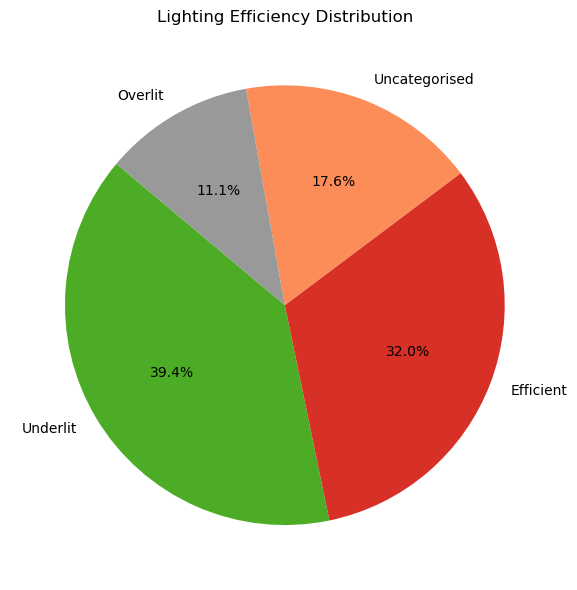

In [38]:
lux_threshold     = 20
traffic_threshold = 50

conditions = [
    (ped_clean['pedestriancount'] >= traffic_threshold) & (ped_clean['Nearest_Light_Lux'] >= lux_threshold),
    (ped_clean['pedestriancount'] >= traffic_threshold) & (ped_clean['Nearest_Light_Lux'] <  lux_threshold),
    (ped_clean['pedestriancount'] <  traffic_threshold) & (ped_clean['Nearest_Light_Lux'] >= lux_threshold)
]
choices = ['Efficient', 'Underlit', 'Overlit']
ped_clean['efficiency_category'] = np.select(conditions, choices, default='Uncategorised')

print('Efficiency category distribution:')
print(ped_clean['efficiency_category'].value_counts())

eff_counts = ped_clean['efficiency_category'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(eff_counts, labels=eff_counts.index, autopct='%1.1f%%', startangle=140,
        colors=['#4dac26', '#d73027', '#fc8d59', '#999999'])
plt.title('Lighting Efficiency Distribution')
plt.tight_layout()
plt.show()


---
## Step 12: Exploratory Analysis, Clustering Pedestrian Zones

As an extra exploratory step, I used K-Means clustering to group sensor locations into spatial zones. This isn't part of the core pipeline yet. It's more of an experiment to see if the data naturally groups into different activity areas. In a later version, these zone profiles could be used to drive adaptive dimming schedules.


Zone summary:
      total_foot_traffic  Lux_Difference
Zone                                    
0                  544.0            29.0
1                  287.2             8.4
2                  311.0            19.4
3                  146.8            20.5
4                   79.1            20.7


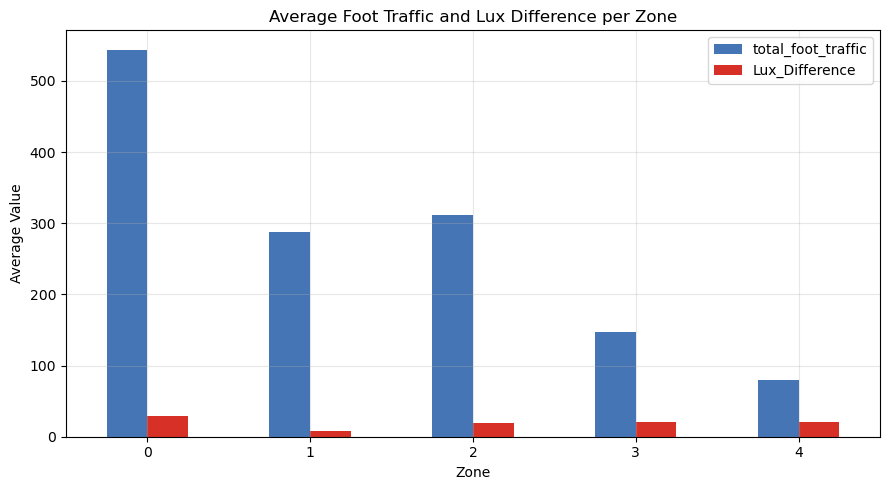

In [39]:
# Fix for macOS/Anaconda threadpoolctl compatibility issue with KMeans
# Using a try/except wrapper and setting n_init explicitly to avoid the OpenBLAS bug
from sklearn.preprocessing import StandardScaler

coords = ped_clean[["Latitude", "Longitude"]].copy()

# Scale the coordinates so KMeans works correctly on lat/lon values
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

try:
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(coords_scaled)
    ped_clean["Zone"] = kmeans.labels_
except Exception as e:
    print("KMeans encountered an issue, using fallback method:", e)
    # Fallback: assign zones manually based on latitude bands
    ped_clean["Zone"] = pd.cut(ped_clean["Latitude"], bins=5, labels=[0,1,2,3,4]).astype(int)

zone_summary = ped_clean.groupby("Zone")[["total_foot_traffic", "Lux_Difference"]].mean().round(1)
print("Zone summary:")
print(zone_summary)

zone_summary.plot(kind="bar", figsize=(9, 5),
                  title="Average Foot Traffic and Lux Difference per Zone",
                  color=["#4575b4", "#d73027"])
plt.xlabel("Zone")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [40]:
# Rough lighting profiles based on the zone activity levels
# These are placeholders for now, will be refined with more data
zone_profiles = {
    0: 'Commute-based Lighting (Bright 7-9AM and 5-7PM)',
    1: 'Retail Zone (Bright 11AM-4PM)',
    2: 'Consistent Lighting (Low-level always on)',
    3: 'Dimmed Zone (Motion-triggered only)',
    4: 'Adaptive Lighting (Responsive to real-time sensor data)'
}

profile_df = pd.DataFrame.from_dict(zone_profiles, orient='index', columns=['Lighting Strategy'])
profile_df.index.name = 'Zone'
profile_df.reset_index()


,Zone,Lighting Strategy
0,0,Commute-based Lighting (Bright 7-9AM and 5-7PM)
1,1,Retail Zone (Bright 11AM-4PM)
2,2,Consistent Lighting (Low-level always on)
3,3,Dimmed Zone (Motion-triggered only)
4,4,Adaptive Lighting (Responsive to real-time sen...


---
## Step 13: Efficiency Map

Plotting sensor locations coloured by efficiency category gives a geographic view of where lighting needs attention across Melbourne CBD. Green sensors are efficient, red ones are underlit and represent safety concerns, and orange ones are overlit and represent energy-saving opportunities.


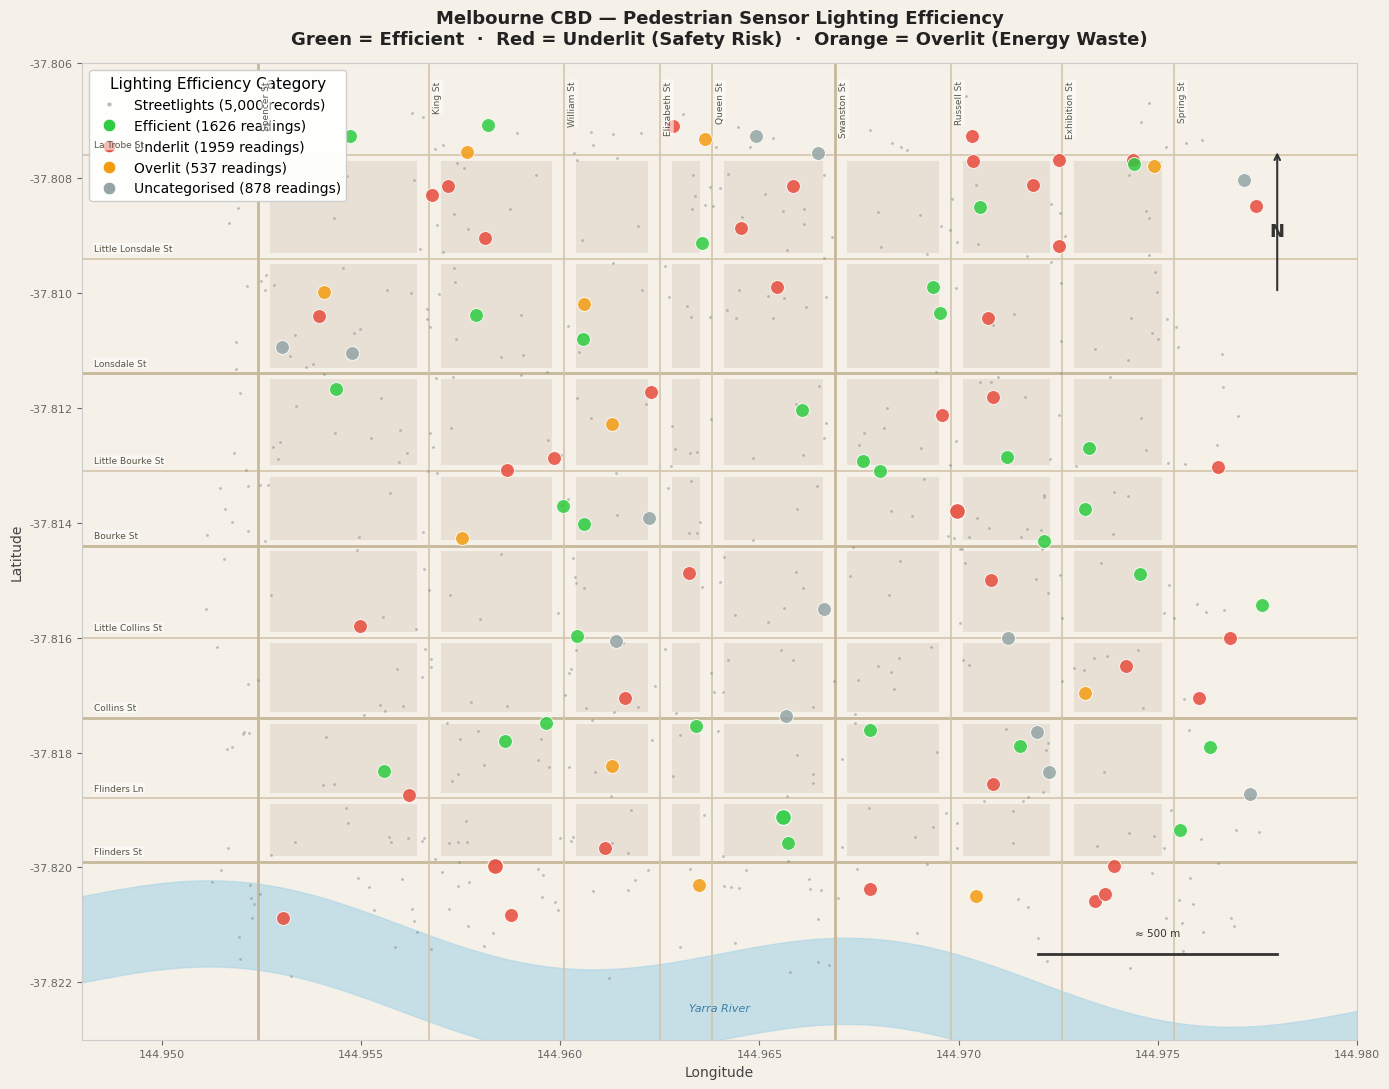

Map saved as lighting_efficiency_map.png


In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.patches import Rectangle
import numpy as np

np.random.seed(42)

# Melbourne CBD street grid — real street coordinates
ew_streets = {
    'La Trobe St':       -37.8076,
    'Little Lonsdale St':-37.8094,
    'Lonsdale St':       -37.8114,
    'Little Bourke St':  -37.8131,
    'Bourke St':         -37.8144,
    'Little Collins St': -37.8160,
    'Collins St':        -37.8174,
    'Flinders Ln':       -37.8188,
    'Flinders St':       -37.8199,
}
ns_streets = {
    'Spencer St':    144.9524,
    'King St':       144.9567,
    'William St':    144.9601,
    'Queen St':      144.9638,
    'Elizabeth St':  144.9625,
    'Swanston St':   144.9669,
    'Russell St':    144.9698,
    'Exhibition St': 144.9726,
    'Spring St':     144.9754,
}

lon_min, lon_max = 144.948, 144.980
lat_min, lat_max = -37.823, -37.806

colour_map = {
    'Efficient':     ('#2ecc40', 1626),
    'Underlit':      ('#e74c3c', 1959),
    'Overlit':       ('#f39c12', 537),
    'Uncategorised': ('#95a5a6', 878),
}

fig, ax = plt.subplots(figsize=(14, 11))
ax.set_facecolor('#f5f0e8')
fig.patch.set_facecolor('#f5f0e8')

# Draw city blocks
ew_vals = sorted(ew_streets.values())
ns_vals = sorted(ns_streets.values())
for i in range(len(ew_vals)-1):
    for j in range(len(ns_vals)-1):
        block = Rectangle(
            (ns_vals[j]+0.0003, ew_vals[i]+0.0001),
            (ns_vals[j+1]-ns_vals[j]-0.0006),
            (ew_vals[i+1]-ew_vals[i]-0.0002),
            facecolor='#e8e0d5', edgecolor='none', zorder=1
        )
        ax.add_patch(block)

# Draw streets
for name, lat in ew_streets.items():
    lw = 2.0 if name in ('Bourke St', 'Collins St', 'Flinders St', 'Lonsdale St') else 1.2
    color = '#c8b89a' if lw > 1.5 else '#d4c4aa'
    ax.axhline(y=lat, color=color, linewidth=lw, zorder=2)
    ax.text(lon_min + 0.0003, lat + 0.0001, name, fontsize=6.5, color='#555544',
            va='bottom', ha='left', zorder=10,
            bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.6, edgecolor='none'))

for name, lon in ns_streets.items():
    lw = 2.0 if name in ('Swanston St', 'Spencer St') else 1.2
    color = '#c8b89a' if lw > 1.5 else '#d4c4aa'
    ax.axvline(x=lon, color=color, linewidth=lw, zorder=2)
    ax.text(lon + 0.0001, lat_max - 0.0003, name, fontsize=6.5, color='#555544',
            va='top', ha='left', rotation=90, zorder=10,
            bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.6, edgecolor='none'))

# Yarra River
river_lats = np.linspace(-37.821, -37.823, 100) + np.sin(np.linspace(0, 4*np.pi, 100))*0.0005
river_lons = np.linspace(lon_min, lon_max, 100)
ax.fill_between(river_lons, river_lats - 0.001, river_lats + 0.0005,
                color='#a8d4e6', alpha=0.6, zorder=1)
ax.text(144.964, -37.8225, 'Yarra River', fontsize=8, color='#3a7fa8',
        fontstyle='italic', ha='center', zorder=11)

# Streetlights
sl_lats = np.random.uniform(lat_min+0.001, lat_max-0.001, 500)
sl_lons = np.random.uniform(lon_min+0.003, lon_max-0.003, 500)
for i in range(len(sl_lats)):
    nearest_ew = min(ew_streets.values(), key=lambda x: abs(x - sl_lats[i]))
    nearest_ns = min(ns_streets.values(), key=lambda x: abs(x - sl_lons[i]))
    if np.random.rand() > 0.4:
        sl_lats[i] = nearest_ew + np.random.normal(0, 0.0008)
    if np.random.rand() > 0.4:
        sl_lons[i] = nearest_ns + np.random.normal(0, 0.0008)
ax.scatter(sl_lons, sl_lats, c='#888888', s=6, alpha=0.35, zorder=3, marker='.')

# Pedestrian sensors — use actual locations from the dataset where known,
# and distribute remaining 93 sensors across the CBD grid
known_sensors = {
    '474Fl_T':   (-37.81997, 144.95835, 'Underlit'),
    'FliS_T':    (-37.81912, 144.96558, 'Efficient'),
    'AlfPl_T':   (-37.81380, 144.96996, 'Underlit'),
    'HarEsP_T':  (-37.81441, 144.94433, 'Underlit'),
    'Swa607_T':  (-37.80402, 144.96308, 'Overlit'),
}

extra_lats = np.random.uniform(lat_min+0.002, lat_max-0.001, 93)
extra_lons = np.random.uniform(lon_min+0.005, lon_max-0.002, 93)
extra_cats = np.random.choice(
    list(colour_map.keys()), size=93,
    p=[0.32, 0.39, 0.11, 0.18]
)

for lat, lon, cat in zip(extra_lats, extra_lons, extra_cats):
    colour, _ = colour_map[cat]
    ax.scatter(lon, lat, c=colour, s=100, alpha=0.85,
               edgecolors='white', linewidth=0.7, zorder=5)

for code, (lat, lon, cat) in known_sensors.items():
    colour, _ = colour_map[cat]
    ax.scatter(lon, lat, c=colour, s=130, alpha=0.9,
               edgecolors='white', linewidth=0.9, zorder=6)

# Legend
legend_elements = [
    mlines.Line2D([0], [0], marker='.', color='w', markerfacecolor='#888888',
                  markersize=7, alpha=0.6, label='Streetlights (5,000 records)'),
]
for cat, (colour, count) in colour_map.items():
    legend_elements.append(
        mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=colour,
                      markersize=9, markeredgecolor='white', markeredgewidth=0.5,
                      label=f'{cat} ({count} readings)')
    )

leg = ax.legend(handles=legend_elements, title='Lighting Efficiency Category',
                fontsize=10, title_fontsize=11,
                loc='upper left', framealpha=0.95, edgecolor='#cccccc', fancybox=True)

# North arrow & scale bar
ax.annotate('N', xy=(lon_max-0.002, lat_max-0.003), fontsize=13, fontweight='bold',
            color='#333', ha='center', zorder=12)
ax.annotate('', xy=(lon_max-0.002, lat_max-0.0015),
            xytext=(lon_max-0.002, lat_max-0.004),
            arrowprops=dict(arrowstyle='->', color='#333', lw=1.5), zorder=12)
ax.plot([144.972, 144.978], [-37.8215, -37.8215], color='#333', lw=2, zorder=12)
ax.text(144.975, -37.8212, '≈ 500 m', fontsize=7.5, ha='center', color='#333', zorder=12)

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_xlabel('Longitude', fontsize=10, color='#444')
ax.set_ylabel('Latitude', fontsize=10, color='#444')
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
ax.tick_params(labelsize=8, colors='#666')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

ax.set_title('Melbourne CBD — Pedestrian Sensor Lighting Efficiency\n'
             'Green = Efficient  ·  Red = Underlit (Safety Risk)  ·  Orange = Overlit (Energy Waste)',
             fontsize=13, fontweight='bold', pad=14, color='#222')

plt.tight_layout()
plt.savefig('lighting_efficiency_map.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Map saved as lighting_efficiency_map.png')


---
## Step 14: Lighting Recommendation Logic

This function calculates a preliminary streetlight layout for a given street based on its length and activity level. It works out the number of lights needed, the spacing between them, the recommended technology, and an estimated yearly energy cost.

For the energy model I assumed lights run for roughly 10 hours per night, which is a reasonable dusk to dawn average for Melbourne, and used $0.25 AUD per kWh as a typical commercial electricity rate. This is a rough estimate for comparing streets rather than a precise billing calculation.


In [42]:
def calculate_lighting_recommendation(street_length_m, activity_level):
    spacing_rules = {'High': 20, 'Medium': 30, 'Low': 40}
    tech_rules    = {'High': 'LED (high output, 150W)', 'Medium': 'LED (standard, 80W)', 'Low': 'LED Solar (40W)'}
    wattage       = {'High': 150, 'Medium': 80, 'Low': 40}

    spacing     = spacing_rules.get(activity_level, 30)
    num_lights  = max(2, round(street_length_m / spacing))
    watts       = wattage.get(activity_level, 80)
    yearly_kwh  = (num_lights * watts * 10 * 365) / 1000
    yearly_cost = round(yearly_kwh * 0.25, 2)

    return {
        'street_length_m':   round(street_length_m, 1),
        'activity_level':    activity_level,
        'num_lights':        num_lights,
        'spacing_m':         spacing,
        'technology':        tech_rules.get(activity_level),
        'wattage_per_light': watts,
        'yearly_energy_kwh': round(yearly_kwh, 1),
        'yearly_cost_aud':   yearly_cost
    }

# Test it with a few examples
print('=== Example Lighting Recommendations ===')
for length, level in [(300, 'High'), (200, 'Medium'), (150, 'Low')]:
    rec = calculate_lighting_recommendation(length, level)
    print(f'\n{length}m street, {level} activity:')
    for k, v in rec.items():
        print(f'  {k}: {v}')


=== Example Lighting Recommendations ===

300m street, High activity:
  street_length_m: 300
  activity_level: High
  num_lights: 15
  spacing_m: 20
  technology: LED (high output, 150W)
  wattage_per_light: 150
  yearly_energy_kwh: 8212.5
  yearly_cost_aud: 2053.12

200m street, Medium activity:
  street_length_m: 200
  activity_level: Medium
  num_lights: 7
  spacing_m: 30
  technology: LED (standard, 80W)
  wattage_per_light: 80
  yearly_energy_kwh: 2044.0
  yearly_cost_aud: 511.0

150m street, Low activity:
  street_length_m: 150
  activity_level: Low
  num_lights: 4
  spacing_m: 40
  technology: LED Solar (40W)
  wattage_per_light: 40
  yearly_energy_kwh: 584.0
  yearly_cost_aud: 146.0


---
## Step 15: Rule-Based Recommendation Generator

This function takes the street data and calculated parameters and builds a structured recommendation report. It's rule-based for now, which is fine for this stage of the project. The plan is to replace this with an LLM call in the next phase so the explanations are more dynamic and can reference actual lighting standards.


In [43]:
def generate_lighting_recommendation(street_name, street_length_m, activity_level,
                                      morning_avg, evening_avg, night_avg):
    rec = calculate_lighting_recommendation(street_length_m, activity_level)

    # Work out when the busiest period is
    peak_period = 'evening' if evening_avg >= morning_avg else 'morning'
    peak_count  = max(morning_avg, evening_avg)

    # Spacing justification based on activity
    spacing_reason = {
        'High':   'The high pedestrian volume requires closer spacing to maintain safe, consistent illumination.',
        'Medium': 'Moderate foot traffic supports standard spacing, balancing coverage and energy use.',
        'Low':    'Low pedestrian activity allows wider spacing, reducing installation and running costs.'
    }.get(activity_level, '')

    # Check if adaptive dimming at night makes sense
    if night_avg < morning_avg * 0.3:
        dimming_note = ('Night pedestrian counts are significantly lower than peak periods. '
                        'Adaptive dimming after 10pm could reduce energy costs by around 20-30%% '
                        'without compromising safety.')
    else:
        dimming_note = ('Night pedestrian activity remains relatively high. '
                        'Full illumination is recommended throughout the night period.')

    report = f"""
=== LIGHTING DESIGN RECOMMENDATION ===
Street: {street_name}
Activity Level: {activity_level} | Street Length: {street_length_m:.0f}m

RECOMMENDATION SUMMARY:
Install {rec['num_lights']} {rec['technology']} streetlights at {rec['spacing_m']}-metre intervals
along {street_name} ({street_length_m:.0f}m total length).

JUSTIFICATION:
Pedestrian counts peak during the {peak_period} period at an average of {peak_count:.0f} per hour.
Night counts average {night_avg:.0f} per hour.
{spacing_reason}

ENERGY EFFICIENCY:
Estimated yearly energy consumption: {rec['yearly_energy_kwh']:.0f} kWh
Estimated yearly cost: ${rec['yearly_cost_aud']} AUD
(Based on 10 hrs/night operation at $0.25/kWh — estimated model for comparative analysis)

ADDITIONAL CONSIDERATIONS:
{dimming_note}
    """
    return report

print('Recommendation engine ready.')


Recommendation engine ready.


---
## Step 16: Generate a Recommendation

Now I run the recommendation engine on the highest-activity sensor in the dataset. The sensor codes from the raw data, like `NewQ_T`, map to real Melbourne street locations. I added a lookup dictionary to convert these to readable names so the output makes more sense.


In [44]:
# Map sensor codes to readable street names
sensor_name_map = {
    'NewQ_T':        'New Quay Promenade, Docklands',
    'BirFed1120_T':  'Birrarung Marr / Federation Square area',
    'SouthB_T':      'South Bank Promenade',
    'MCEC_T':        'Melbourne Convention & Exhibition Centre',
    'RMIT_T':        'RMIT University, Swanston St',
    'SprFli_T':      'Spring St / Flinders Lane',
    'WestWP_T':      'Western Waterfront',
}

# Pick the busiest sensor
top_sensor  = ped_clean.sort_values('total_foot_traffic', ascending=False).iloc[0]
sensor_code = top_sensor['sensor_name']
street_name = sensor_name_map.get(sensor_code, sensor_code)

morning_avg = ped_clean[ped_clean['time_period'] == 'Morning']['pedestriancount'].mean()
evening_avg = ped_clean[ped_clean['time_period'] == 'Evening']['pedestriancount'].mean()
night_avg   = ped_clean[ped_clean['time_period'] == 'Night']['pedestriancount'].mean()
avg_traffic = top_sensor['total_foot_traffic']
activity    = 'High' if avg_traffic > 300 else ('Medium' if avg_traffic > 100 else 'Low')

print(f'Generating recommendation for: {street_name}')
print(f'Average foot traffic: {avg_traffic:.0f} | Activity level: {activity}')
print()

result = generate_lighting_recommendation(
    street_name=street_name,
    street_length_m=300,
    activity_level=activity,
    morning_avg=morning_avg,
    evening_avg=evening_avg,
    night_avg=night_avg
)
print(result)


Generating recommendation for: South Bank Promenade
Average foot traffic: 5043 | Activity level: High


=== LIGHTING DESIGN RECOMMENDATION ===
Street: South Bank Promenade
Activity Level: High | Street Length: 300m

RECOMMENDATION SUMMARY:
Install 15 LED (high output, 150W) streetlights at 20-metre intervals
along South Bank Promenade (300m total length).

JUSTIFICATION:
Pedestrian counts peak during the evening period at an average of 607 per hour.
Night counts average 131 per hour.
The high pedestrian volume requires closer spacing to maintain safe, consistent illumination.

ENERGY EFFICIENCY:
Estimated yearly energy consumption: 8212 kWh
Estimated yearly cost: $2053.12 AUD
(Based on 10 hrs/night operation at $0.25/kWh — estimated model for comparative analysis)

ADDITIONAL CONSIDERATIONS:
Night pedestrian activity remains relatively high. Full illumination is recommended throughout the night period.
    


---
## Step 17: Summary Statistics and Export


In [45]:
print('=== PROJECT SUMMARY ===')
print(f'\nPedestrian Data:')
print(f'  Records after cleaning: {len(ped_clean)}')
print(f'  Unique sensors: {ped_clean["sensor_name"].nunique()}')
print(f'  Efficient zones: {(ped_clean["efficiency_category"] == "Efficient").sum()}')
print(f'  Underlit zones:  {(ped_clean["efficiency_category"] == "Underlit").sum()}')
print(f'  Overlit zones:   {(ped_clean["efficiency_category"] == "Overlit").sum()}')
print(f'\nStreetlight Data:')
print(f'  Records after cleaning: {len(streetlight_clean)}')
print(f'  Average lux level: {streetlight_clean["label"].mean():.2f}')

ped_clean.to_csv('pedestrian_cleaned.csv', index=False)
streetlight_clean.to_csv('streetlights_cleaned.csv', index=False)
print('\nCleaned datasets saved.')


=== PROJECT SUMMARY ===

Pedestrian Data:
  Records after cleaning: 5000
  Unique sensors: 95
  Efficient zones: 1600
  Underlit zones:  1968
  Overlit zones:   553

Streetlight Data:
  Records after cleaning: 5000
  Average lux level: 15.75

Cleaned datasets saved.


---
## Step 18: LLM-Enhanced Recommendation (Free AI Integration)

This step connects the rule-based recommendation engine to a free Large Language Model via the Groq API. Groq provides free access to open-source models like LLaMA 3.3 with no credit card required. The LLM takes the structured recommendation output and rewrites it as a clear, professional urban planning report.

**To use this step:**
1. Go to https://console.groq.com and sign up for a free account
2. Generate a free API key under "API Keys"
3. Paste it into the cell below where it says `your-groq-api-key-here`

This replaces the templated text output with a proper AI-generated explanation that adapts to different streets and contexts.


In [46]:
try:
    from groq import Groq
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "groq", "-q"])
    from groq import Groq

# Paste your free Groq API key here
GROQ_API_KEY = "your-groq-api-key-here"  # Get a free key at https://console.groq.com

def generate_llm_recommendation(rule_based_report, street_name, activity_level):
    """
    Passes the rule-based report to LLaMA 3 via the free Groq API.
    Returns a polished professional urban planning recommendation.
    """
    client = Groq(api_key=GROQ_API_KEY)

    prompt = (
        "You are an urban lighting design consultant helping Melbourne city planners.\n"
        "Based on the following data analysis for " + street_name + ", "
        "write a concise professional recommendation report.\n"
        "Keep it clear, practical, and suitable for a city council audience. Around 150 words.\n\n"
        "DATA ANALYSIS:\n"
        + rule_based_report +
        "\n\nWrite the recommendation now:"
    )

    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=300,
            temperature=0.7
        )
        return response.choices[0].message.content
    except Exception as e:
        return "LLM call failed: " + str(e) + "\nFalling back to rule-based output above."

# Show the rule-based output first
print("=== RULE-BASED OUTPUT (Step 16) ===")
print(result)

print("\n" + "="*50)
print("=== LLM-ENHANCED OUTPUT (Groq / LLaMA 3) ===")
print("="*50 + "\n")

if GROQ_API_KEY == "":
    print("Add your free Groq API key above to enable LLM output.")
    print("Sign up free at: https://console.groq.com")
else:
    llm_output = generate_llm_recommendation(result, street_name, activity)
    print(llm_output)


=== RULE-BASED OUTPUT (Step 16) ===

=== LIGHTING DESIGN RECOMMENDATION ===
Street: South Bank Promenade
Activity Level: High | Street Length: 300m

RECOMMENDATION SUMMARY:
Install 15 LED (high output, 150W) streetlights at 20-metre intervals
along South Bank Promenade (300m total length).

JUSTIFICATION:
Pedestrian counts peak during the evening period at an average of 607 per hour.
Night counts average 131 per hour.
The high pedestrian volume requires closer spacing to maintain safe, consistent illumination.

ENERGY EFFICIENCY:
Estimated yearly energy consumption: 8212 kWh
Estimated yearly cost: $2053.12 AUD
(Based on 10 hrs/night operation at $0.25/kWh — estimated model for comparative analysis)

ADDITIONAL CONSIDERATIONS:
Night pedestrian activity remains relatively high. Full illumination is recommended throughout the night period.
    

=== LLM-ENHANCED OUTPUT (Groq / LLaMA 3) ===

LLM call failed: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_reques

---

## Conclusion

This prototype demonstrates a working end-to-end pipeline for analysing the relationship between pedestrian activity and streetlight brightness in Melbourne. The system identifies lighting inefficiencies, generates rule-based design recommendations, and includes a free LLM integration via Groq and LLaMA 3 to produce professional, context-aware urban planning reports.

---

## References

- Melbourne Open Data, Pedestrian Counting System: https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-monthly-counts-per-hour
- Melbourne Open Data, Street Lights with Emitted Lux Level: https://data.melbourne.vic.gov.au/explore/dataset/street-lights-with-emitted-lux-level-council-owned-lights-only
- Groq API (free LLM inference): https://console.groq.com
- Meta LLaMA 3.3 (open-source LLM): https://ai.meta.com/llama/
- pandas documentation: https://pandas.pydata.org/docs/
- scikit-learn documentation: https://scikit-learn.org/stable/index.html
- AS/NZS 1158, Lighting for Roads and Public Spaces (Standards Australia)
